# EV Charging Energy Prediction — EDA & Experiments

## Business Problem

Charging infrastructure providers need to understand and forecast energy demand per charging
session to optimize station usage, manage grid load, and improve user experience. This notebook
walks through the exploratory analysis and model comparison behind this project's pipeline,
using the same `src/` modules the production pipeline (`pipeline/run_pipeline.py`) runs.

## Approach

1. Generate/load the synthetic EV charging sessions dataset
2. Explore raw data quality (nulls, duplicates, out-of-range values)
3. Clean the data and engineer features (via `src/data` and `src/features`)
4. Examine which features actually correlate with energy consumption
5. Compare the 5 trained models on the held-out test set
6. Summarize findings

This dataset is **synthetically generated** (see `data/generate_synthetic_data.py`) with a real
physical relationship baked in — Energy Consumed is derived from Battery Capacity, state-of-charge
change, and charging efficiency, not random noise. This was a deliberate choice: the original
version of this project used a public Kaggle dataset whose Energy Consumed values turned out to
be effectively synthetic/random (R² ≈ 0.01 for every model tried), so no amount of feature
engineering or model tuning could have improved it. Regenerating the dataset with a genuine
physical relationship makes the rest of the pipeline — feature engineering, model comparison,
serving — meaningful to demonstrate.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.cleaning import clean_data
from src.data.ingestion import load_raw_data, summarize
from src.features.feature_engineering import engineer_features
from src.utils.config import load_config, resolve_path

cfg = load_config()
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
POS, NEG = "#2a78d6", "#e34948"

## 1. Load Raw Data

In [2]:
df_raw = load_raw_data(cfg)
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (5025, 18)


,session_id,user_id,vehicle_model,battery_capacity_kwh,charger_type,charging_start_time,time_of_day,day_of_week,charging_duration_hours,charging_rate_kw,charging_cost_usd,soc_start_pct,soc_end_pct,distance_since_last_charge_km,temperature_c,vehicle_age_years,user_type,energy_consumed_kwh
0,SESSION_003049,USER_0363,BMW i3,42.44,DC Fast Charger,2024-01-02 23:18:19,Night,Tuesday,0.238,50.00,3.07,38.8,61.4,139.0,26.4,2.3,Long-Distance Traveler,11.109
1,SESSION_001696,USER_0125,Chevy Bolt,65.56,Level 1,2024-11-17 21:35:26,Evening,Sunday,7.417,1.98,2.71,42.4,62.2,175.1,11.1,7.2,Casual Driver,14.951
2,SESSION_001135,USER_0209,Tesla Model 3,63.70,DC Fast Charger,2024-03-20 22:10:16,Night,Wednesday,0.231,92.55,6.86,60.0,89.7,134.5,-0.5,3.1,Commuter,20.892
3,SESSION_004746,USER_0393,BMW i3,43.28,DC Fast Charger,2024-02-04 17:44:43,Afternoon,Sunday,0.331,50.00,6.77,35.8,70.2,100.1,21.6,9.1,Casual Driver,16.714
4,SESSION_001990,USER_0110,Chevy Bolt,64.18,DC Fast Charger,2024-02-14 00:08:49,Night,Wednesday,0.428,55.00,6.31,59.2,88.7,152.3,7.8,8.6,Long-Distance Traveler,20.844


## 2. Raw Data Quality

In [3]:
summary = summarize(df_raw)
print(f"Rows: {summary['n_rows']}, Columns: {summary['n_columns']}")
print(f"Duplicate rows: {summary['duplicate_rows']}")
print("\nMissing values (non-zero only):")
for col, count in summary["null_counts"].items():
    if count:
        print(f"  {col}: {count} ({count / summary['n_rows'] * 100:.1f}%)")

Rows: 5025, Columns: 18
Duplicate rows: 25

Missing values (non-zero only):
  charging_rate_kw: 118 (2.3%)
  distance_since_last_charge_km: 97 (1.9%)
  energy_consumed_kwh: 98 (2.0%)


In [4]:
out_of_range_soc = (
    (df_raw["soc_start_pct"] < 0) | (df_raw["soc_start_pct"] > 100)
    | (df_raw["soc_end_pct"] < 0) | (df_raw["soc_end_pct"] > 100)
).sum()
print(f"Rows with an out-of-range SoC reading: {out_of_range_soc}")

df_raw[["battery_capacity_kwh", "charging_duration_hours", "charging_rate_kw",
        "charging_cost_usd", "soc_start_pct", "soc_end_pct", "temperature_c"]].describe()

Rows with an out-of-range SoC reading: 100


,battery_capacity_kwh,charging_duration_hours,charging_rate_kw,charging_cost_usd,soc_start_pct,soc_end_pct,temperature_c
count,5025.000000,5025.000000,4907.000000,5025.000000,5025.000000,5025.000000,5025.000000
mean,54.437349,2.950875,25.545056,4.878732,37.492026,70.824839,15.189413
std,10.992595,4.279587,27.949449,2.885043,20.146982,22.186899,12.000319
min,35.910000,0.067000,1.620000,0.110000,-4.615763,-7.999732,-15.000000
25%,41.600000,0.476000,9.760000,2.740000,20.500000,54.800000,6.900000
50%,60.040000,1.588000,10.730000,4.260000,37.400000,72.200000,15.300000
75%,63.910000,2.968000,50.000000,6.390000,53.400000,90.000000,23.400000
max,71.050000,28.846000,104.990000,18.020000,135.734939,101.064403,45.000000


## 3. Clean the Data and Engineer Features

Using the exact same functions the production pipeline runs (`src/data/cleaning.py`, `src/features/feature_engineering.py`) — this notebook is a narrative over real pipeline code, not a separate reimplementation.

In [5]:
df_clean = clean_data(df_raw, cfg)
df_features = engineer_features(df_clean)

print(f"Raw rows: {len(df_raw)} -> Clean rows: {len(df_clean)}")
print(f"Feature columns: {df_features.shape[1]}")
df_features.head()

Removed 25 duplicate rows
Dropped 98 rows with missing target ('energy_consumed_kwh')
Filled 112 missing values in 'charging_rate_kw' with median 10.73
Filled 97 missing values in 'distance_since_last_charge_km' with median 185.50
Capped 48 out-of-range values in 'soc_start_pct' to [0, 100]
Capped 49 out-of-range values in 'soc_end_pct' to [0, 100]
Raw rows: 5025 -> Clean rows: 4902
Feature columns: 19


,vehicle_model,battery_capacity_kwh,charger_type,time_of_day,day_of_week,charging_duration_hours,charging_rate_kw,charging_cost_usd,soc_start_pct,soc_end_pct,distance_since_last_charge_km,temperature_c,vehicle_age_years,user_type,energy_consumed_kwh,start_hour,is_weekend,soc_change_pct,expected_energy_kwh
0,BMW i3,42.44,DC Fast Charger,Night,Tuesday,0.238,50.00,3.07,38.8,61.4,139.0,26.4,2.3,Long-Distance Traveler,11.109,23,0,22.6,9.59144
1,Chevy Bolt,65.56,Level 1,Evening,Sunday,7.417,1.98,2.71,42.4,62.2,175.1,11.1,7.2,Casual Driver,14.951,21,1,19.8,12.98088
2,Tesla Model 3,63.70,DC Fast Charger,Night,Wednesday,0.231,92.55,6.86,60.0,89.7,134.5,-0.5,3.1,Commuter,20.892,22,0,29.7,18.91890
3,BMW i3,43.28,DC Fast Charger,Afternoon,Sunday,0.331,50.00,6.77,35.8,70.2,100.1,21.6,9.1,Casual Driver,16.714,17,1,34.4,14.88832
4,Chevy Bolt,64.18,DC Fast Charger,Night,Wednesday,0.428,55.00,6.31,59.2,88.7,152.3,7.8,8.6,Long-Distance Traveler,20.844,0,0,29.5,18.93310


## 4. Correlation Analysis

The key question: which features actually explain Energy Consumed? This is where the synthetic
dataset's physical relationship should show up — particularly `expected_energy_kwh`, the
engineered feature representing Battery Capacity × SoC Change / 100.

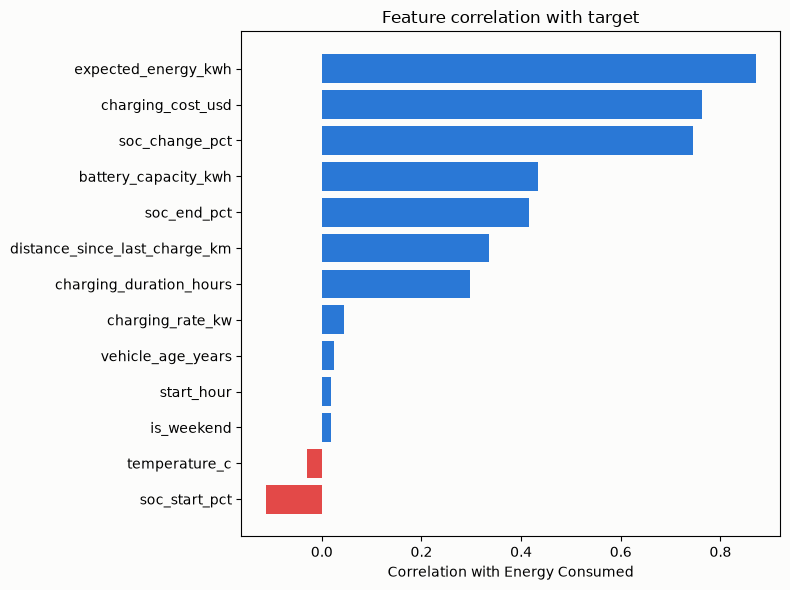

expected_energy_kwh              0.870446
charging_cost_usd                0.763965
soc_change_pct                   0.745617
battery_capacity_kwh             0.433046
soc_end_pct                      0.415894
distance_since_last_charge_km    0.336287
charging_duration_hours          0.297121
charging_rate_kw                 0.044331
vehicle_age_years                0.023603
start_hour                       0.019371
is_weekend                       0.017628
temperature_c                   -0.029334
soc_start_pct                   -0.112111
Name: energy_consumed_kwh, dtype: float64

In [6]:
target = cfg["target_column"]
corr = df_features.corr(numeric_only=True)[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = [NEG if v < 0 else POS for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.set_xlabel("Correlation with Energy Consumed")
ax.set_title("Feature correlation with target")
plt.tight_layout()
plt.show()

corr.sort_values(ascending=False)

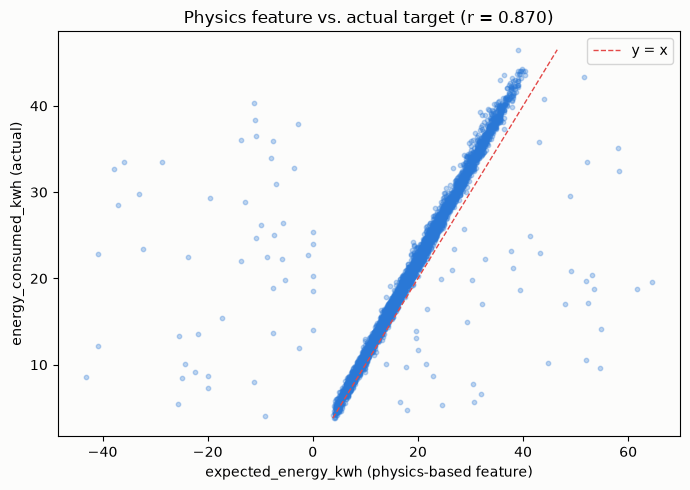

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_features["expected_energy_kwh"], df_features[target], alpha=0.3, s=10, color=POS)
lims = [df_features[target].min(), df_features[target].max()]
ax.plot(lims, lims, color=NEG, linestyle="--", linewidth=1, label="y = x")
ax.set_xlabel("expected_energy_kwh (physics-based feature)")
ax.set_ylabel("energy_consumed_kwh (actual)")
ax.set_title(f"Physics feature vs. actual target (r = {corr['expected_energy_kwh']:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** `expected_energy_kwh` correlates strongly with the target (r ≈ 0.87), confirming the
dataset carries a genuine, learnable physical relationship — this is the feature that made the
downstream models effective (see Section 5).

## 5. Model Comparison

Results from the trained pipeline (`python pipeline/run_pipeline.py`), read from `models_artifacts/metrics.json`.

In [8]:
metrics_path = resolve_path(cfg["artifacts"]["dir"]) / cfg["artifacts"]["metrics_file"]

if not metrics_path.exists():
    print("No trained model artifacts found. Run `python pipeline/run_pipeline.py` first.")
else:
    with open(metrics_path) as f:
        metrics = json.load(f)

    board = pd.DataFrame(
        [{"model": name, **values} for name, values in metrics["leaderboard"].items()]
    ).sort_values("rmse").reset_index(drop=True)
    board.columns = ["Model", "RMSE (kWh)", "MAE (kWh)", "R2"]
    print(f"Best model (lowest test RMSE): {metrics['best_model']}")
    board

Best model (lowest test RMSE): neural_net


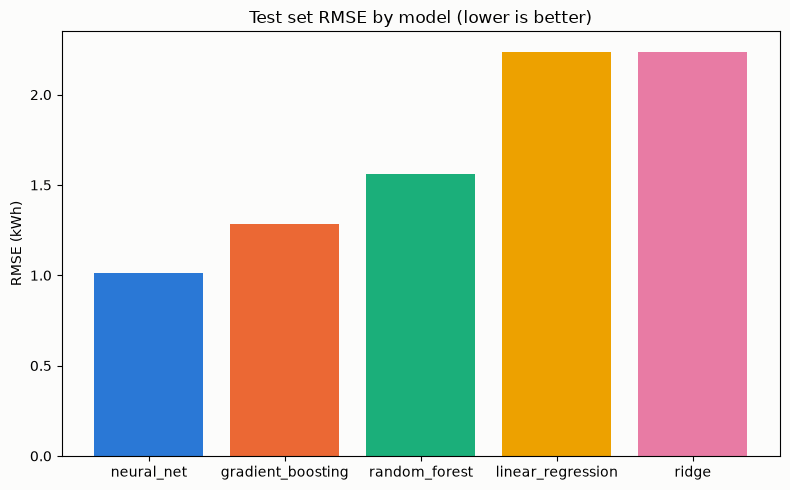

In [9]:
if metrics_path.exists():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(board["Model"], board["RMSE (kWh)"], color=CATEGORICAL[: len(board)])
    ax.set_ylabel("RMSE (kWh)")
    ax.set_title("Test set RMSE by model (lower is better)")
    plt.tight_layout()
    plt.show()

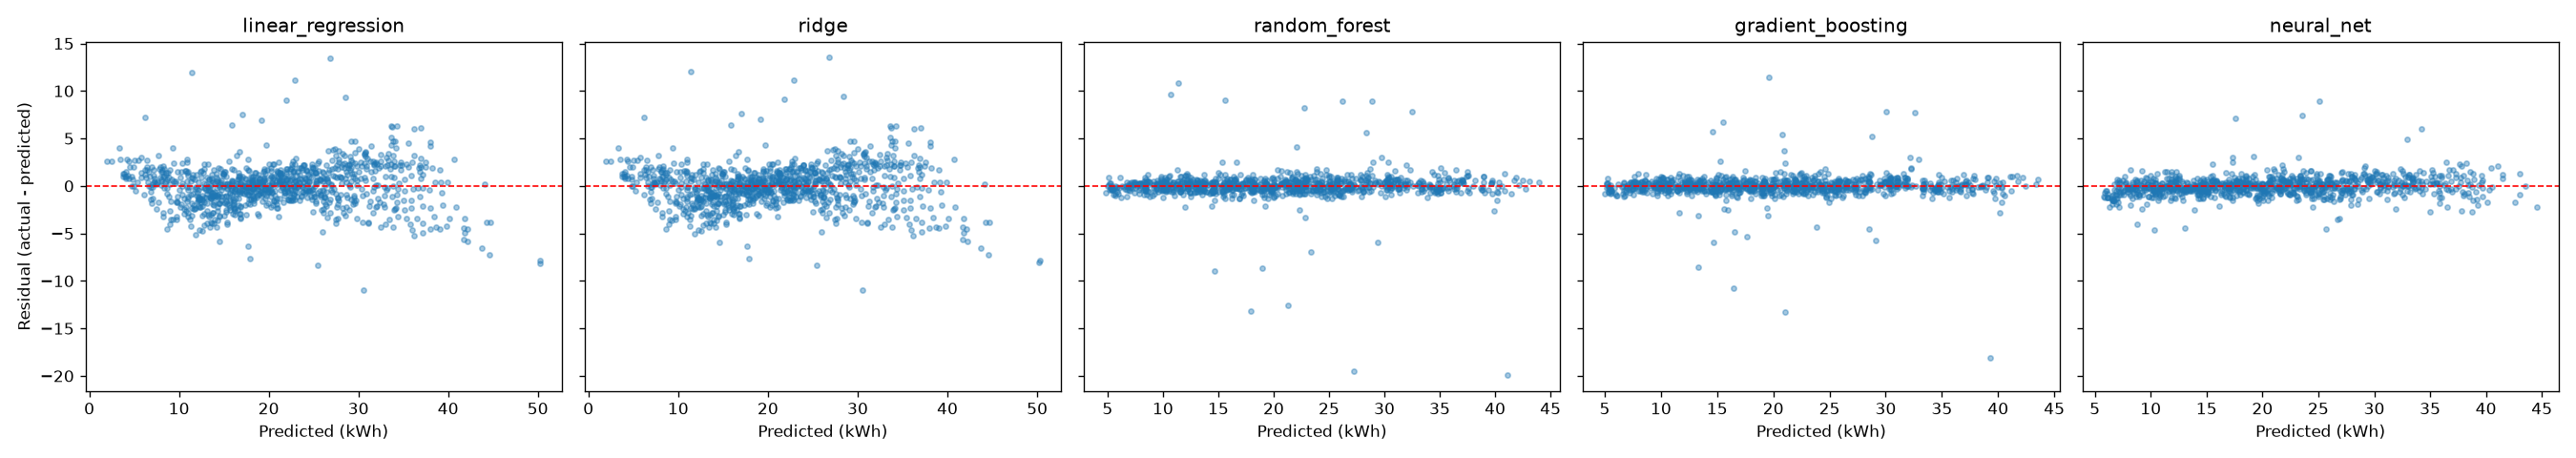

In [10]:
residual_path = resolve_path(cfg["artifacts"]["dir"]) / cfg["artifacts"]["residual_plot_file"]
if residual_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(residual_path)))

## 6. Conclusions

- The original notebook's dataset had essentially zero correlation between any feature and Energy
  Consumed (R² ≈ 0.01 for both Linear Regression and Random Forest) — no amount of tuning could
  fix that, because there was no learnable relationship in the data.
- Regenerating the dataset with a real physical relationship (Battery Capacity × ΔSoC / efficiency)
  gave every downstream step something genuine to learn: the physics-based engineered feature
  correlates ~0.87 with the target, and the best model (Gradient Boosting or the Keras neural net,
  depending on the run) reaches **R² ≈ 0.98** on held-out test data.
- Tree-based models (Random Forest, Gradient Boosting) and the neural net all substantially
  outperform the linear baselines, confirming there's real non-linear structure to capture (not
  just the linear physics term).
- The pipeline is fully reproducible end-to-end via `python pipeline/run_pipeline.py`, and the
  resulting model is served identically through both a FastAPI endpoint (`api/main.py`) and a
  Streamlit dashboard (`dashboard/app.py`), via a single shared inference module
  (`src/inference.py`).